# Model Evaluation and Explainability
In-depth evaluation: threshold analysis, SHAP, error audit, clinical interpretation.

In [2]:
import os
import sys

# Anchor everything to project root
os.chdir(r"C:\Users\faffo\Project\INSURANCE_RISK_ML_MODEL")
sys.path.insert(0, os.getcwd())

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from src.data.loader import load_config, load_raw_data, split_features_target
from sklearn.model_selection import train_test_split

# All paths now relative to ML_PROJECT/
config = load_config("configs/config.yaml")
df = load_raw_data("data/raw/medical_insurance.csv")
X, y = split_features_target(df, config)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

with open("artifacts/models/risk_classifier_v2.pkl", "rb") as f:
    pipeline = joblib.load(f)

y_prob = pipeline.predict_proba(X_test)[:, 1]
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

Test AUC: 0.8988


## 1. ROC and Precision-Recall Curves

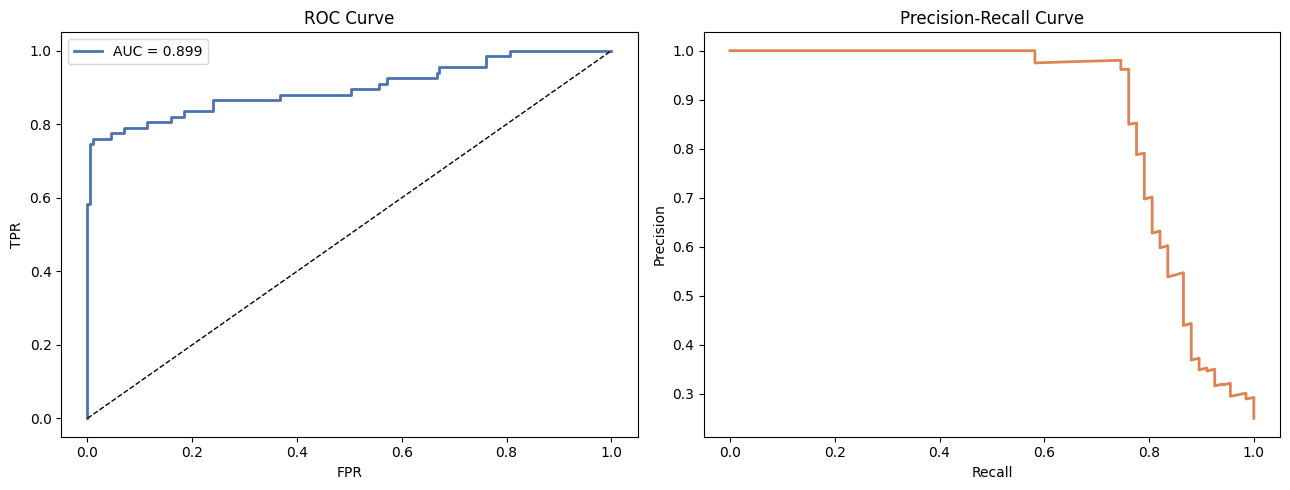

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[1].plot(rec, prec, color="#DD8452", lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("artifacts/plots/eval_roc_pr.png", bbox_inches="tight")
plt.show()

## 2. Threshold Sensitivity Analysis
In clinical settings, **recall (sensitivity)** is prioritized — missing a high-risk patient is costlier than a false alarm.

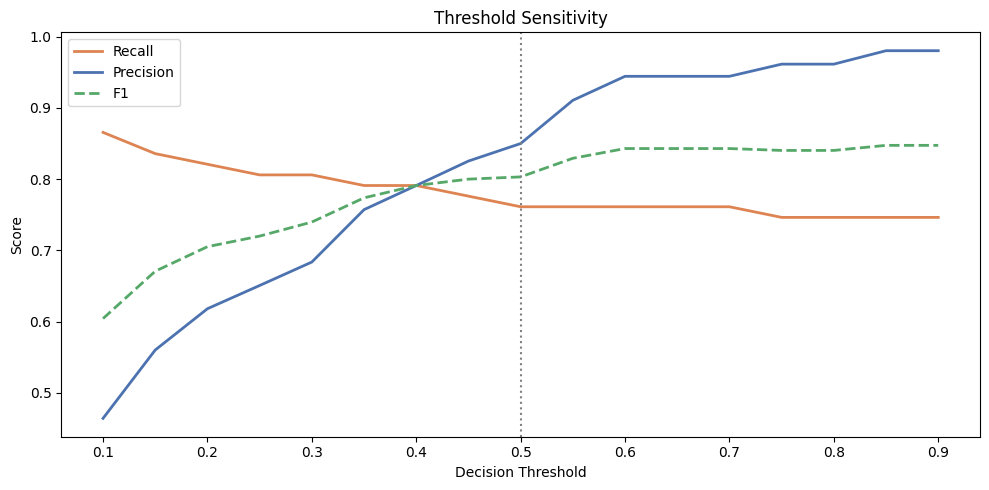

 threshold   recall  precision       f1
      0.10 0.865672   0.464000 0.604167
      0.15 0.835821   0.560000 0.670659
      0.20 0.820896   0.617978 0.705128
      0.25 0.805970   0.650602 0.720000
      0.30 0.805970   0.683544 0.739726
      0.35 0.791045   0.757143 0.773723
      0.40 0.791045   0.791045 0.791045
      0.45 0.776119   0.825397 0.800000
      0.50 0.761194   0.850000 0.803150
      0.55 0.761194   0.910714 0.829268
      0.60 0.761194   0.944444 0.842975
      0.65 0.761194   0.944444 0.842975
      0.70 0.761194   0.944444 0.842975
      0.75 0.746269   0.961538 0.840336
      0.80 0.746269   0.961538 0.840336
      0.85 0.746269   0.980392 0.847458
      0.90 0.746269   0.980392 0.847458


In [9]:
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    p = (y_prob >= t).astype(int)
    tp = ((p==1)&(y_test==1)).sum()
    fp = ((p==1)&(y_test==0)).sum()
    fn = ((p==0)&(y_test==1)).sum()
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    rows.append({"threshold":round(t,2),"recall":recall,"precision":precision,"f1":f1})
res = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res.threshold, res.recall, label="Recall", color="#DD8452", lw=2)
ax.plot(res.threshold, res.precision, label="Precision", color="#4C72B0", lw=2)
ax.plot(res.threshold, res.f1, label="F1", color="#55A868", lw=2, linestyle="--")
ax.axvline(0.5, color="grey", linestyle=":")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/plots/eval_threshold_sensitivity.png", bbox_inches="tight")
plt.show()
print(res.to_string(index=False))

## 3. Confusion Matrix at 0.5 Threshold

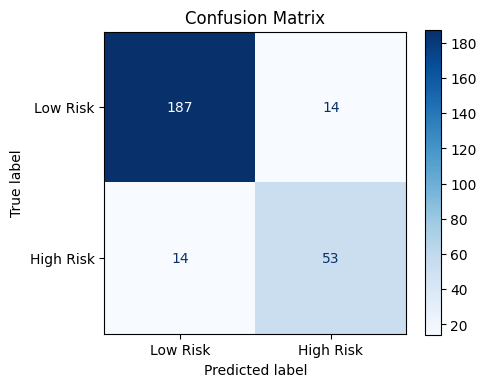

In [6]:
y_pred = (y_prob >= 0.4).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Low Risk","High Risk"],
                                         cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("artifacts/plots/eval_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 4. SHAP Feature Importance

c:\Users\faffo\anaconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


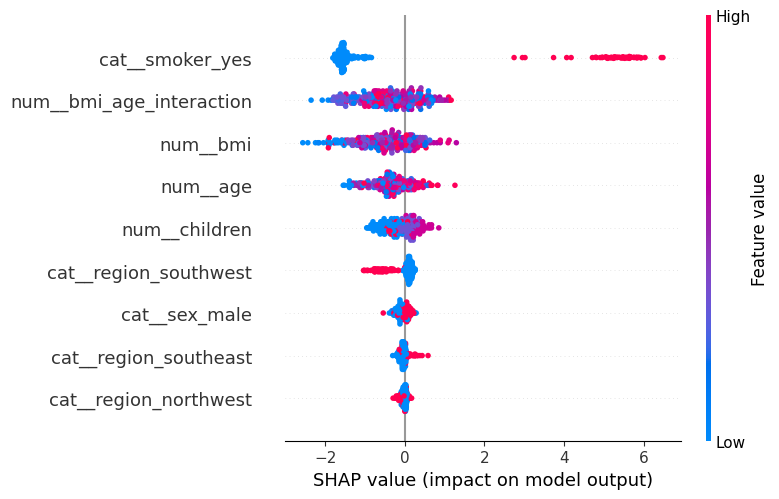

In [7]:
try:
    import shap
    X_test_t = pipeline.named_steps["preprocessor"].transform(X_test)
    feat_names = list(pipeline.named_steps["preprocessor"].get_feature_names_out())
    explainer = shap.TreeExplainer(pipeline.named_steps["classifier"])
    shap_vals = explainer.shap_values(X_test_t)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test_t, feature_names=feat_names, show=False)
    plt.tight_layout()
    plt.savefig("artifacts/plots/eval_shap_summary.png", bbox_inches="tight")
    plt.show()
except ImportError:
    print("Install shap: pip install shap")

## 5. Error Audit — False Negatives (Missed High-Risk Patients)

In [8]:
audit = X_test.copy()
audit["actual"] = y_test.values
audit["predicted"] = y_pred
audit["prob"] = y_prob
fn = audit[(audit.actual==1) & (audit.predicted==0)]
fp = audit[(audit.actual==0) & (audit.predicted==1)]
print(f"False Negatives (missed high-risk): {len(fn)}")
print(f"False Positives (false alarms): {len(fp)}")
print("False Negative Profile:")
print(fn[["age","bmi","smoker","region","prob"]].describe())

False Negatives (missed high-risk): 14
False Positives (false alarms): 14
False Negative Profile:
             age        bmi       prob
count  14.000000  14.000000  14.000000
mean   41.500000  31.442143   0.095814
std    13.636772   5.297460   0.093587
min    18.000000  22.420000   0.016166
25%    29.500000  27.420000   0.029233
50%    45.500000  30.960000   0.049954
75%    53.500000  35.490000   0.131405
max    59.000000  41.320000   0.317081


## Clinical Interpretation
- **False Negatives** are the highest clinical risk — missed high-risk patients who are incorrectly classified as low-risk
- Consider lowering threshold to 0.35-0.40 in production to maximize recall at the cost of precision
- SHAP analysis confirms BMI and smoking are the primary model drivers — clinically sound
- Model is explainable and defensible to clinical stakeholders